Fig. 1E bottom panel

In [12]:
suppressPackageStartupMessages({
library(tidyverse)
library(ggplot2)
library(showtext)
library(sysfonts)
library(patchwork)
})

# Download Roboto from Google Font, which is same as in Biorender
font_add_google("Roboto", "roboto")

# Enable showtext rendering
showtext_auto()

# Optional: set a default theme with Roboto for all plots
theme_set(theme_grey(base_family = "roboto") +
          theme( text = element_text(color = "black"))
          )

In [13]:
WD <- "data/"
data_set <- read.csv(paste0(WD, "PIK3CA_signal.csv"), header = TRUE, row.names = 1)
data_set <- data_set / 10^5
head(data_set)

Warning message in read.table(file = file, header = header, sep = sep, quote = quote, :
“incomplete final line found by readTableHeader on '~/Cas12a optimisation/PIK3CA_signal.csv'”


,NTC_A,NTC_A.1,NTC_A.2,U2OS_A,U2OS_A.1,U2OS_A.2,T47D_A,T47D_A.1,T47D_A.2,NTC_T,⋯,T47D_G.2,NTC_C,NTC_C.1,NTC_C.2,U2OS_C,U2OS_C.1,U2OS_C.2,T47D_C,T47D_C.1,T47D_C.2
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,0.0000000,0.00000000,0.0000000,0.00000000,0.0000000,0.0000000,0.0000000,0.0000000,0.00000000,0.00000000,⋯,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.0000000,0.000000,0.000000,0.000000
5,-0.0766262,-0.07660920,-0.1719063,-0.07433060,-0.0577291,-0.0893290,-0.0561057,-0.0364415,-0.05103390,-0.04426756,⋯,-0.03066830,-0.04197668,-0.02573366,-0.03862332,-0.01563026,-0.03618070,-0.0366555,4.850352,4.326151,4.348095
10,-0.0991744,-0.09023410,-0.1886665,-0.09628205,-0.0909713,-0.1198028,-0.0821754,-0.0608694,-0.08104335,-0.05399640,⋯,-0.04811540,-0.04611665,-0.03828828,-0.04704704,-0.02413806,-0.03875740,-0.0396643,9.614920,8.482392,8.580373
15,-0.1134232,-0.08912258,-0.1966776,-0.09829300,-0.0975027,-0.1212749,-0.0892893,-0.0676699,-0.09336040,-0.04534730,⋯,-0.05840384,-0.04759785,-0.04359516,-0.05320067,-0.04040486,-0.03424914,-0.0474754,12.579508,11.362695,11.502423


In [3]:
#split into each 3'end nucleotide
bases <- c("A", "T", "G", "C")
data_list <- list()

for (base in bases) {
    df_base <- data_set[, grepl(paste0("_", base), colnames(data_set))]
    data_list[[base]] <- df_base
}
head(data_list[["A"]])

,NTC_A,NTC_A.1,NTC_A.2,U2OS_A,U2OS_A.1,U2OS_A.2,T47D_A,T47D_A.1,T47D_A.2
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,0.0000000,0.00000000,0.0000000,0.00000000,0.0000000,0.0000000,0.0000000,0.0000000,0.00000000
5,-0.0766262,-0.07660920,-0.1719063,-0.07433060,-0.0577291,-0.0893290,-0.0561057,-0.0364415,-0.05103390
10,-0.0991744,-0.09023410,-0.1886665,-0.09628205,-0.0909713,-0.1198028,-0.0821754,-0.0608694,-0.08104335
15,-0.1134232,-0.08912258,-0.1966776,-0.09829300,-0.0975027,-0.1212749,-0.0892893,-0.0676699,-0.09336040


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


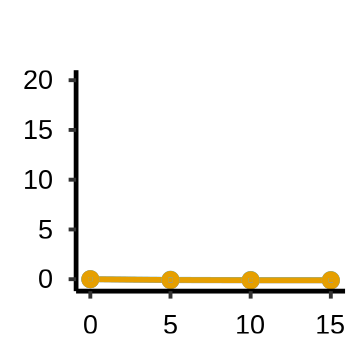

In [4]:
options(repr.plot.width = 3, repr.plot.height =3) 

checking_base <- "A"

# Reshape into long format
df_long <- data_list[[checking_base]] %>%
  rownames_to_column("time") %>%
  pivot_longer(
    cols = -time,                # exclude 'time' from pivoting
    names_to = "condition_raw",
    values_to = "value"
  ) %>%
  separate(condition_raw, into = c("condition", "replicate"), sep = "\\.", fill = "right") %>%
  mutate(
    replicate = ifelse(is.na(replicate), 1, as.numeric(replicate) + 1),  # crRNA1 -> rep1, .1 -> rep2, .2 -> rep3
    time = as.numeric(time)                                             # convert time back to numeric
  )

df_summary <- df_long %>%
  group_by(time, condition) %>%
  summarise(mean = mean(value), sd = sd(value), .groups = "drop")

#remove 3'nucleotide
df_summary$condition <- sub("_.*", "", df_summary$condition)

#specify
colours <- c("NTC" = "#999999",
             "U2OS" = "#E69F00",
             "T47D" = "#56B4E9"
            )

a <- ggplot(df_summary, aes(x = time, y = mean, color = condition)) +
  geom_line(size = 1.2) +
  geom_point(size = 4) +
  geom_errorbar(aes(ymin = mean - sd, ymax = mean + sd), width = 0.25, size = 0.8) +
  scale_color_manual(values = colours, name = NULL) +
  ylim(NA, 20) +
  labs( title = "",
    x = "Time (min)",
  ) +
  ylab((expression(Delta * " Fluorescence ( AU " * x~10^5 * " )")))+
  theme_bw(base_size = 18) +
  theme(
    axis.title.x = element_blank(),  
    axis.title.y = element_blank(),  
    axis.text = element_text(size = 20, color = "black"),
    axis.text.x = element_text(vjust = 1, hjust = 0.5,margin = margin(t = 10)), #vjust controls vertical justification (up/down) and hjust controls horizontal justification (left/right)
    axis.text.y = element_text(vjust = 0.5, hjust = 1,margin = margin(r = 10)),
    legend.position = "none", 
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", size = 1),
    plot.title = element_text(
    hjust = 0.5,   # center
    size = 24,     # increase size (adjust as needed)
    color = "black",
    margin = margin(t = 15)
  )
  )
a
ggsave(paste0(WD,"PIK3CA_signal_", checking_base, ".pdf"), plot = last_plot(), width = 3, height = 3, units = "in")

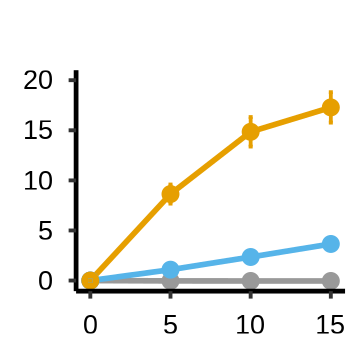

In [5]:
options(repr.plot.width = 3, repr.plot.height =3) 

checking_base <- "T"

# Reshape into long format
df_long <- data_list[[checking_base]] %>%
  rownames_to_column("time") %>%
  pivot_longer(
    cols = -time,                # exclude 'time' from pivoting
    names_to = "condition_raw",
    values_to = "value"
  ) %>%
  separate(condition_raw, into = c("condition", "replicate"), sep = "\\.", fill = "right") %>%
  mutate(
    replicate = ifelse(is.na(replicate), 1, as.numeric(replicate) + 1),  # crRNA1 -> rep1, .1 -> rep2, .2 -> rep3
    time = as.numeric(time)                                             # convert time back to numeric
  )

df_summary <- df_long %>%
  group_by(time, condition) %>%
  summarise(mean = mean(value), sd = sd(value), .groups = "drop")

#remove 3'nucleotide
df_summary$condition <- sub("_.*", "", df_summary$condition)

#specify
colours <- c("NTC" = "#999999",
             "U2OS" = "#E69F00",
             "T47D" = "#56B4E9"
            )

t <- ggplot(df_summary, aes(x = time, y = mean, color = condition)) +
  geom_line(size = 1.2) +
  geom_point(size = 4) +
  geom_errorbar(aes(ymin = mean - sd, ymax = mean + sd), width = 0.25, size = 0.8) +
  scale_color_manual(values = colours, name = NULL) +
  ylim(NA, 20) +
  labs( title = "",
    x = "Time (min)",
  ) +
  ylab((expression(Delta * " Fluorescence ( AU " * x~10^5 * " )")))+
  theme_bw(base_size = 18) +
  theme(
    axis.title.x = element_blank(),  
    axis.title.y = element_blank(),  
    axis.text = element_text(size = 20, color = "black"),
    axis.text.x = element_text(vjust = 1, hjust = 0.5,margin = margin(t = 10)), #vjust controls vertical justification (up/down) and hjust controls horizontal justification (left/right)
    axis.text.y = element_text(vjust = 0.5, hjust = 1,margin = margin(r = 10)),
    legend.position = "none", 
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", size = 1),
    plot.title = element_text(
    hjust = 0.5,   # center
    size = 24,     # increase size (adjust as needed)
    color = "black",
    margin = margin(t = 15)
  )
  )
t
ggsave(paste0(WD,"PIK3CA_signal_", checking_base, ".pdf"), plot = last_plot(), width = 3, height = 3, units = "in")

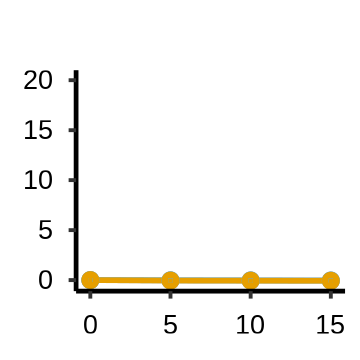

In [6]:
options(repr.plot.width = 3, repr.plot.height =3) 

checking_base <- "G"

# Reshape into long format
df_long <- data_list[[checking_base]] %>%
  rownames_to_column("time") %>%
  pivot_longer(
    cols = -time,                # exclude 'time' from pivoting
    names_to = "condition_raw",
    values_to = "value"
  ) %>%
  separate(condition_raw, into = c("condition", "replicate"), sep = "\\.", fill = "right") %>%
  mutate(
    replicate = ifelse(is.na(replicate), 1, as.numeric(replicate) + 1),  # crRNA1 -> rep1, .1 -> rep2, .2 -> rep3
    time = as.numeric(time)                                             # convert time back to numeric
  )

df_summary <- df_long %>%
  group_by(time, condition) %>%
  summarise(mean = mean(value), sd = sd(value), .groups = "drop")

#remove 3'nucleotide
df_summary$condition <- sub("_.*", "", df_summary$condition)

#specify
colours <- c("NTC" = "#999999",
             "U2OS" = "#E69F00",
             "T47D" = "#56B4E9"
            )

g <- ggplot(df_summary, aes(x = time, y = mean, color = condition)) +
  geom_line(size = 1.2) +
  geom_point(size = 4) +
  geom_errorbar(aes(ymin = mean - sd, ymax = mean + sd), width = 0.25, size = 0.8) +
  scale_color_manual(values = colours, name = NULL) +
  ylim(NA, 20) +
  labs( title = "",
    x = "Time (min)",
  ) +
  ylab((expression(Delta * " Fluorescence ( AU " * x~10^5 * " )")))+
  theme_bw(base_size = 18) +
  theme(
    axis.title.x = element_blank(),  
    axis.title.y = element_blank(),  
    axis.text = element_text(size = 20, color = "black"),
    axis.text.x = element_text(vjust = 1, hjust = 0.5,margin = margin(t = 10)), #vjust controls vertical justification (up/down) and hjust controls horizontal justification (left/right)
    axis.text.y = element_text(vjust = 0.5, hjust = 1,margin = margin(r = 10)),
    legend.position = "none", 
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", size = 1),
    plot.title = element_text(
    hjust = 0.5,   # center
    size = 24,     # increase size (adjust as needed)
    color = "black",
    margin = margin(t = 15)
  )
  )
g
ggsave(paste0(WD,"PIK3CA_signal_", checking_base, ".pdf"), plot = last_plot(), width = 3, height = 3, units = "in")

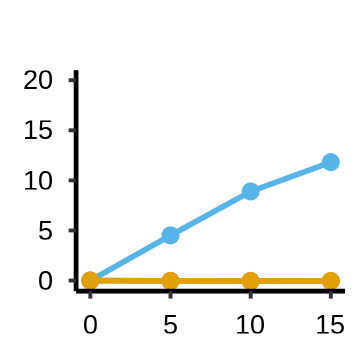

In [7]:
options(repr.plot.width = 3, repr.plot.height =3) 

checking_base <- "C"

# Reshape into long format
df_long <- data_list[[checking_base]] %>%
  rownames_to_column("time") %>%
  pivot_longer(
    cols = -time,                # exclude 'time' from pivoting
    names_to = "condition_raw",
    values_to = "value"
  ) %>%
  separate(condition_raw, into = c("condition", "replicate"), sep = "\\.", fill = "right") %>%
  mutate(
    replicate = ifelse(is.na(replicate), 1, as.numeric(replicate) + 1),  # crRNA1 -> rep1, .1 -> rep2, .2 -> rep3
    time = as.numeric(time)                                             # convert time back to numeric
  )

df_summary <- df_long %>%
  group_by(time, condition) %>%
  summarise(mean = mean(value), sd = sd(value), .groups = "drop")

#remove 3'nucleotide
df_summary$condition <- sub("_.*", "", df_summary$condition)

#specify
colours <- c("NTC" = "#999999",
             "U2OS" = "#E69F00",
             "T47D" = "#56B4E9"
            )

c <- ggplot(df_summary, aes(x = time, y = mean, color = condition)) +
  geom_line(size = 1.2) +
  geom_point(size = 4) +
  geom_errorbar(aes(ymin = mean - sd, ymax = mean + sd), width = 0.25, size = 0.8) +
  scale_color_manual(values = colours, name = NULL) +
  ylim(NA, 20) +
  labs( title = "",
    x = "Time (min)",
  ) +
  ylab((expression(Delta * " Fluorescence ( AU " * x~10^5 * " )")))+
  theme_bw(base_size = 18) +
  theme(
    axis.title.x = element_blank(),  
    axis.title.y = element_blank(),  
    axis.text = element_text(size = 20, color = "black"),
    axis.text.x = element_text(vjust = 1, hjust = 0.5,margin = margin(t = 10)), #vjust controls vertical justification (up/down) and hjust controls horizontal justification (left/right)
    axis.text.y = element_text(vjust = 0.5, hjust = 1,margin = margin(r = 10)),
    legend.position = "none", 
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", size = 1),
    plot.title = element_text(
    hjust = 0.5,   # center
    size = 24,     # increase size (adjust as needed)
    color = "black",
    margin = margin(t = 15)
  )
  )
c
ggsave(paste0(WD,"PIK3CA_signal_", checking_base, ".pdf"), plot = last_plot(), width = 3, height = 3, units = "in")

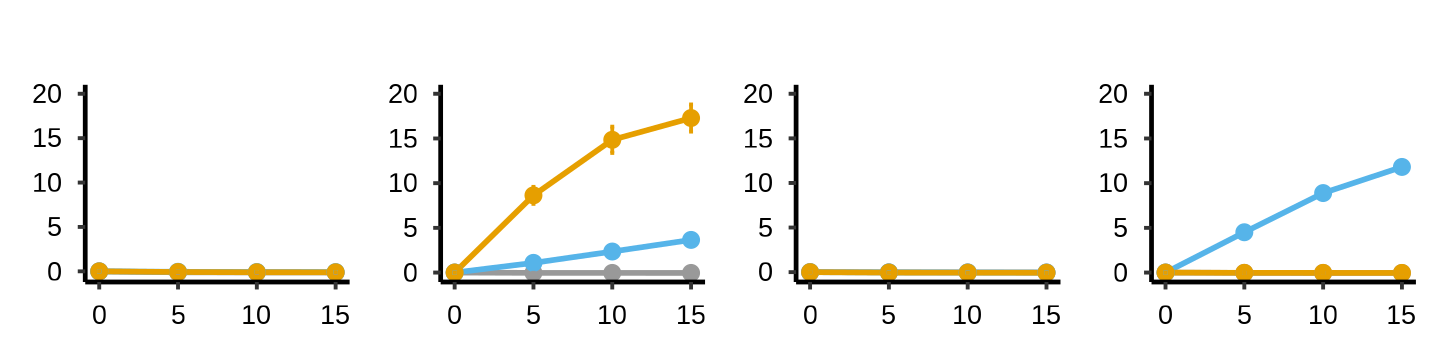

In [8]:
options(repr.plot.width = 12, repr.plot.height =3) 
(a | t | g | c)

In [9]:
ggsave(paste0(WD,"PIK3CA_signal_combined.pdf"), plot = last_plot(), width = 12, height = 3, units = "in")

In [10]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /software/cellgen/team205/si9/envs/Seurat/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: Europe/London
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] patchwork_1.3.2 showtext_0.9-7  showtextdb_3.0  sysfonts_0.8.9 
 [5] lubridate_1.9.4 forcats_1.0.0   stringr_1.5.2   dplyr_1.1.4    
 [9] purrr_1.1.0     readr_2.1.5     tidyr_1.3.1     tibble_3.3.0   
[13] ggplot2_3.5.2   tidyverse_2.0.0

loaded via a namespace (and not attached):
 [1] gtable_0.3.6       